In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings('ignore')

# 1차 모델

In [2]:
filepath = "./B1_종합실습2_전처리데이터(SVM_NN).csv"
df_raw = pd.read_csv(filepath, encoding='utf-8')

In [3]:
df_raw.columns

Index(['scale', 'pt_thick', 'pt_width', 'hsb', 'fur_heat_temp',
       'fur_heat_time', 'fur_soak_temp', 'fur_soak_time', 'rolling_temp',
       'descaling_count', 'steel_kind_C', 'steel_kind_T', 'fur_no_1호기',
       'fur_no_2호기', 'fur_no_3호기', 'fur_input_row_1열', 'fur_input_row_2열',
       'rolling_method_CR(제어압연)', 'rolling_method_TMCP(온도제어)', 'work_group_1조',
       'work_group_2조', 'work_group_3조', 'work_group_4조', 'class_code_ABS',
       'class_code_API', 'class_code_ASTM', 'class_code_BV', 'class_code_CCS',
       'class_code_Common', 'class_code_DNV', 'class_code_GL', 'class_code_JS',
       'class_code_KR', 'class_code_KS', 'class_code_LR', 'class_code_NK'],
      dtype='object')

In [4]:
df_raw_x = df_raw.drop("scale", axis = 1, inplace = False)
df_raw_y = df_raw["scale"] 

display("설명변수:", df_raw_x.head())
display("목표변수:",df_raw_y.tail())

'설명변수:'

,pt_thick,pt_width,hsb,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,rolling_temp,descaling_count,steel_kind_C,...,class_code_BV,class_code_CCS,class_code_Common,class_code_DNV,class_code_GL,class_code_JS,class_code_KR,class_code_KS,class_code_LR,class_code_NK
0,0.287834,1.757877,1,-0.623753,1.140313,-1.034166,-0.617721,-0.099397,2,0,...,0,0,0,0,0,0,0,0,0,0
1,0.287834,1.757877,1,-0.623753,1.368163,-0.918797,-0.909098,-0.052252,2,0,...,0,0,0,0,0,0,0,0,0,0
2,0.342996,1.555380,1,-1.330154,1.140313,-1.726379,-0.811972,-0.806566,2,0,...,0,0,0,1,0,0,0,0,0,0
3,0.342996,1.555380,1,-0.247005,1.482088,-1.380272,-0.180654,-0.869425,2,0,...,0,0,0,1,0,0,0,0,0,0
4,0.618805,0.542895,1,-0.812126,1.823863,-1.322588,-1.151913,-1.058004,2,0,...,1,0,0,0,0,0,0,0,0,0


'목표변수:'

995    0
996    0
997    0
998    0
999    0
Name: scale, dtype: int64

In [5]:
# 변환된 설명변수 데이터 사용:df_x_converted 
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_raw_x, df_raw_y
                                    , test_size = 0.4, random_state = 1986)

print("분할된 Train Data: {}".format(df_train_x.shape))
print("분할된 Test Data: {}".format(df_test_x.shape))

분할된 Train Data: (600, 35)
분할된 Test Data: (400, 35)


In [6]:
nn_uncust = MLPClassifier(random_state=1986)
nn_uncust.fit(df_train_x, df_train_y)

# train 모델 정확도
print("Train Accuracy: {:.3f}".format(nn_uncust.score(df_train_x, df_train_y)))
# test 모델 정확도
print("Test Accuracy: {:.3f}".format(nn_uncust.score(df_test_x, df_test_y)))

Train Accuracy: 0.945
Test Accuracy: 0.880


In [7]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
para_hidden = [5 * hidden for hidden in range(1, 21)]  # 은닉층 노드 

print(para_hidden)

for v_hidden in para_hidden:
#     nn = MLPClassifier(hidden_layer_sizes = v_hidden, random_state = 1234) # 은닉층 : 1D (5,), (10,)...
    nn = MLPClassifier(hidden_layer_sizes = (v_hidden,v_hidden), random_state = 1986) # 은닉층 : 2D (5,5), (10,10)...
    nn.fit(df_train_x, df_train_y)
    train_accuracy.append(nn.score(df_train_x, df_train_y))
    test_accuracy.append(nn.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_hidden = pd.DataFrame()
df_accuracy_hidden["HiddenLayer"] = para_hidden
df_accuracy_hidden["TrainAccuracy"] = train_accuracy
df_accuracy_hidden["TestAccuracy"] = test_accuracy

[5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]


In [8]:
df_accuracy_hidden.round(3)

,HiddenLayer,TrainAccuracy,TestAccuracy
0,5,0.867,0.822
1,10,0.922,0.860
2,15,0.937,0.860
3,20,0.950,0.855
4,25,0.952,0.860
5,30,0.970,0.882
6,35,0.967,0.870
7,40,0.978,0.875
8,45,0.992,0.870
9,50,0.987,0.860


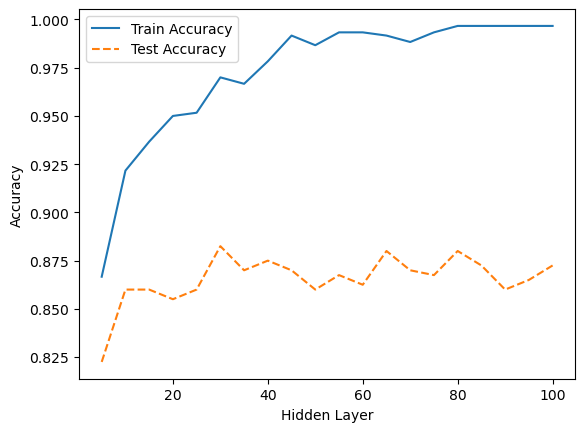

In [9]:
plt.plot(para_hidden, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_hidden, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Hidden Layer")
plt.legend()

In [10]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# activation 변경 
para_function = ["logistic", "tanh", "relu"]

for v_function in para_function:
    nn = MLPClassifier(activation = v_function, hidden_layer_sizes=(40,40), random_state = 1986)
    nn.fit(df_train_x, df_train_y)
    train_accuracy.append(nn.score(df_train_x, df_train_y))
    test_accuracy.append(nn.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_function = pd.DataFrame()
df_accuracy_function["ActivationFunction"] = para_function
df_accuracy_function["TrainAccuracy"] = train_accuracy
df_accuracy_function["TestAccuracy"] = test_accuracy

In [11]:
df_accuracy_function.round(3)

,ActivationFunction,TrainAccuracy,TestAccuracy
0,logistic,0.863,0.838
1,tanh,0.957,0.892
2,relu,0.978,0.875


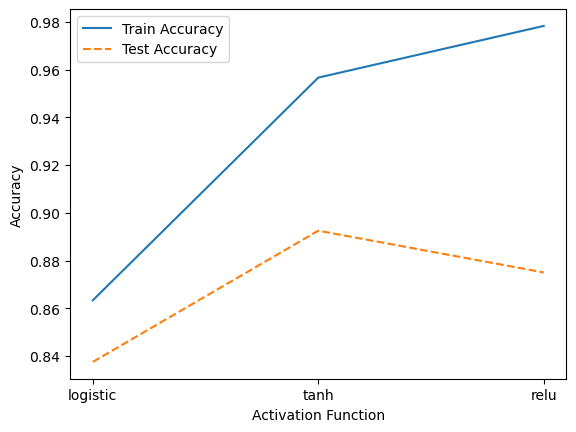

In [12]:
plt.plot(para_function, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_function, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Activation Function")
plt.legend()

In [13]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# solver 변경 
para_solver = ["lbfgs", "sgd", "adam"]

for v_solver in para_solver:
    nn = MLPClassifier(solver = v_solver, activation="tanh", hidden_layer_sizes=(40,40), random_state = 1986)
    nn.fit(df_train_x, df_train_y)
    train_accuracy.append(nn.score(df_train_x, df_train_y))
    test_accuracy.append(nn.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_solver = pd.DataFrame()
df_accuracy_solver["Solver"] = para_solver
df_accuracy_solver["TrainAccuracy"] = train_accuracy
df_accuracy_solver["TestAccuracy"] = test_accuracy

In [14]:
df_accuracy_solver.round(3)

,Solver,TrainAccuracy,TestAccuracy
0,lbfgs,1.000,0.858
1,sgd,0.850,0.825
2,adam,0.957,0.892


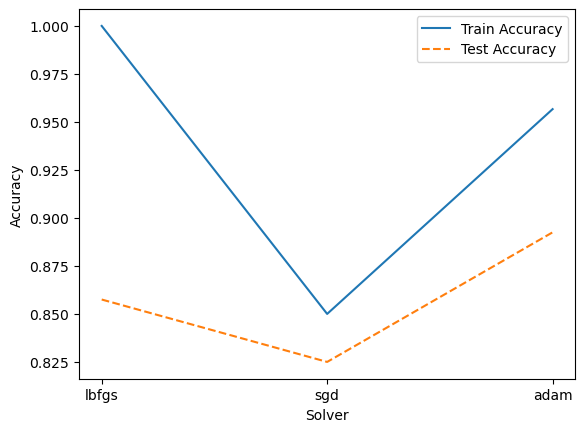

In [15]:
# 정확도 그래프 확인
plt.plot(para_solver, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_solver, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Solver")
plt.legend()

In [16]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# Mini Batch 변경
para_batch = [20 * batch for batch in range(1, 10)] 

print(para_batch)

for v_batch in para_batch:
    nn = MLPClassifier(batch_size = v_batch, solver = "adam", activation = "tanh", 
                       hidden_layer_sizes = (40,40), random_state = 1986)
    nn.fit(df_train_x, df_train_y)
    train_accuracy.append(nn.score(df_train_x, df_train_y))
    test_accuracy.append(nn.score(df_test_x, df_test_y))    

# 데이터 테이블로 저장
df_accuracy_batch = pd.DataFrame()
df_accuracy_batch["Mini Batch"] = para_batch
df_accuracy_batch["TrainAccuracy"] = train_accuracy
df_accuracy_batch["TestAccuracy"] = test_accuracy

[20, 40, 60, 80, 100, 120, 140, 160, 180]


In [17]:
df_accuracy_batch.round(3)

,Mini Batch,TrainAccuracy,TestAccuracy
0,20,0.997,0.898
1,40,0.992,0.888
2,60,0.990,0.892
3,80,0.987,0.885
4,100,0.982,0.885
5,120,0.977,0.895
6,140,0.977,0.890
7,160,0.972,0.892
8,180,0.965,0.885


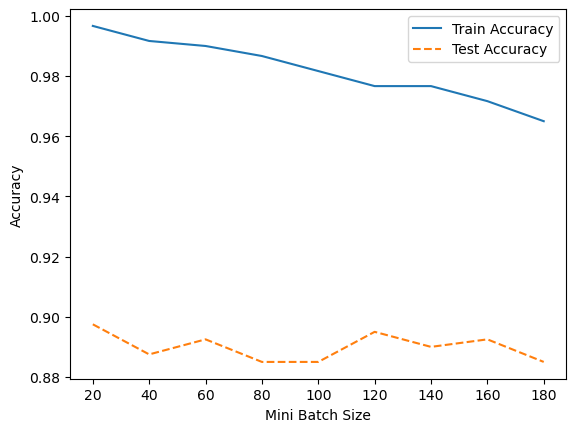

In [18]:
# 모델 정확도 그래프 확인
plt.plot(para_batch, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_batch, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Mini Batch Size")
plt.legend()

In [19]:
from sklearn.metrics import confusion_matrix, classification_report

In [20]:
# 최종 모델
nn_final = MLPClassifier(hidden_layer_sizes=(40, 40), activation="tanh", solver="adam"
                         , batch_size =20, random_state = 1986)
nn_final.fit(df_train_x, df_train_y)

# 평가
y_pred_train = nn_final.predict(df_train_x)
y_proba_train = nn_final.predict_proba(df_train_x)[:, 1]
y_pred_test = nn_final.predict(df_test_x)
y_proba_test = nn_final.predict_proba(df_test_x)[:, 1]

# train 모델 정확도
print("Train Accucary : {:.3f}".format(nn_final.score(df_train_x, df_train_y)))
# test 모델 정확도
print("Test Accuracy : {:.3f}\n".format(nn_final.score(df_test_x, df_test_y)))
# confusion matrix
print("Test Confusion Matrix: \n{}".format(confusion_matrix(df_test_y, y_pred_test)))

# 목표변수의 빈도 불균형 : f1 score로 모델 평가 
print(classification_report(df_test_y, y_pred_test, digits=3))

Train Accucary : 0.997
Test Accuracy : 0.897

Test Confusion Matrix: 
[[264  13]
 [ 28  95]]
              precision    recall  f1-score   support

           0      0.904     0.953     0.928       277
           1      0.880     0.772     0.823       123

    accuracy                          0.897       400
   macro avg      0.892     0.863     0.875       400
weighted avg      0.897     0.897     0.896       400



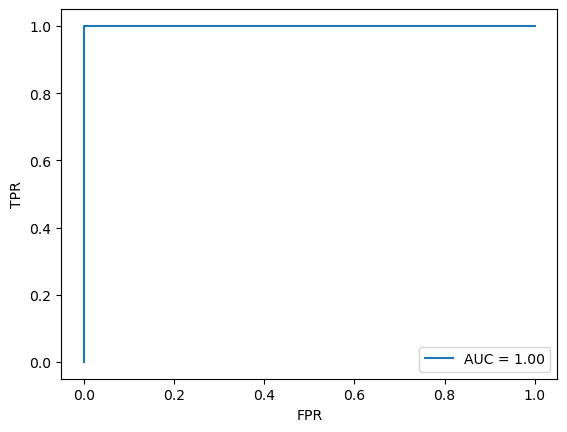

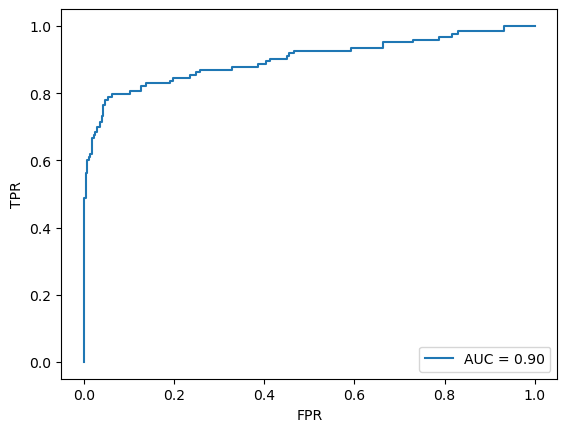

             NN-train   NN-test
Accuracy     0.996667  0.897500
Precision    1.000000  0.879630
Recall       0.989305  0.772358
F1_score     0.994624  0.822511
Specificity  1.000000  0.953069


In [21]:
from sklearn.metrics import roc_curve, auc

def print_metric(y_true, y_pred, y_pred_proba, data_name): # 실제값, 예측값, ROC 커브이미지 저장이름 ex)RF-train
    cm = confusion_matrix(y_true, y_pred)
    TP = cm[1][1]
    TN = cm[0][0]
    FP = cm[0][1]
    FN = cm[1][0]

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1_score = 2 * (precision * recall) / (precision + recall)
    specificity = TN / (TN + FP)

    metric_list = [accuracy, precision,recall, f1_score, specificity]
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label= "AUC = %0.2f"% roc_auc)
    plt.legend(loc="lower right")
    plt.ylabel("TPR"); plt.xlabel("FPR") 
    plt.savefig(data_name+"_roc_curve.png")
    plt.show()
    
    return pd.DataFrame(metric_list, index=['Accuracy', 'Precision', 'Recall', 'F1_score', 'Specificity'])
    
metric_df_first = pd.DataFrame()
metric_list_train = print_metric(df_train_y, y_pred_train,y_proba_train, "NN-train")
metric_list_test = print_metric(df_test_y, y_pred_test, y_proba_test, "NN-test")

metric_df_first['NN-train'] = metric_list_train
metric_df_first['NN-test'] = metric_list_test

print(metric_df_first)

# 2차 모델

In [26]:
filepath = "./B1_종합실습2_전처리데이터(2차_svm_nn).csv"
df_raw = pd.read_csv(filepath, encoding='utf-8')

In [27]:
df_raw_x = df_raw.drop("scale", axis = 1, inplace = False)
df_raw_y = df_raw["scale"] 

display("설명변수:", df_raw_x.head())
display("목표변수:",df_raw_y.tail())

'설명변수:'

,pt_thick,pt_width,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,rolling_temp,steel_kind_C,steel_kind_T,rolling_method_CR(제어압연),...,class_code_BV,class_code_CCS,class_code_Common,class_code_DNV,class_code_GL,class_code_JS,class_code_KR,class_code_KS,class_code_LR,class_code_NK
0,0.287834,1.757877,-0.623753,1.140313,-1.034166,-0.617721,-0.099397,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0.287834,1.757877,-0.623753,1.368163,-0.918797,-0.909098,-0.052252,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0.342996,1.555380,-1.330154,1.140313,-1.726379,-0.811972,-0.806566,0,1,0,...,0,0,0,1,0,0,0,0,0,0
3,0.342996,1.555380,-0.247005,1.482088,-1.380272,-0.180654,-0.869425,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0.618805,0.542895,-0.812126,1.823863,-1.322588,-1.151913,-1.058004,0,1,0,...,1,0,0,0,0,0,0,0,0,0


'목표변수:'

995    0
996    0
997    0
998    0
999    0
Name: scale, dtype: int64

In [28]:
# 변환된 설명변수 데이터 사용:df_x_converted 
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_raw_x, df_raw_y
                                    , test_size = 0.4, random_state = 1986)

print("분할된 Train Data: {}".format(df_train_x.shape))
print("분할된 Test Data: {}".format(df_test_x.shape))

분할된 Train Data: (600, 28)
분할된 Test Data: (400, 28)


In [29]:
# 최종 모델
nn_final = MLPClassifier(hidden_layer_sizes=(40, 40), activation="tanh", solver="adam"
                         , batch_size =20, random_state = 1986)
nn_final.fit(df_train_x, df_train_y)

# 평가
y_pred_train = nn_final.predict(df_train_x)
y_proba_train = nn_final.predict_proba(df_train_x)[:, 1]
y_pred_test = nn_final.predict(df_test_x)
y_proba_test = nn_final.predict_proba(df_test_x)[:, 1]

# train 모델 정확도
print("Train Accucary : {:.3f}".format(nn_final.score(df_train_x, df_train_y)))
# test 모델 정확도
print("Test Accuracy : {:.3f}\n".format(nn_final.score(df_test_x, df_test_y)))
# confusion matrix
print("Test Confusion Matrix: \n{}".format(confusion_matrix(df_test_y, y_pred_test)))

# 목표변수의 빈도 불균형 : f1 score로 모델 평가 
print(classification_report(df_test_y, y_pred_test, digits=3))

Train Accucary : 0.977
Test Accuracy : 0.805

Test Confusion Matrix: 
[[246  31]
 [ 47  76]]
              precision    recall  f1-score   support

           0      0.840     0.888     0.863       277
           1      0.710     0.618     0.661       123

    accuracy                          0.805       400
   macro avg      0.775     0.753     0.762       400
weighted avg      0.800     0.805     0.801       400



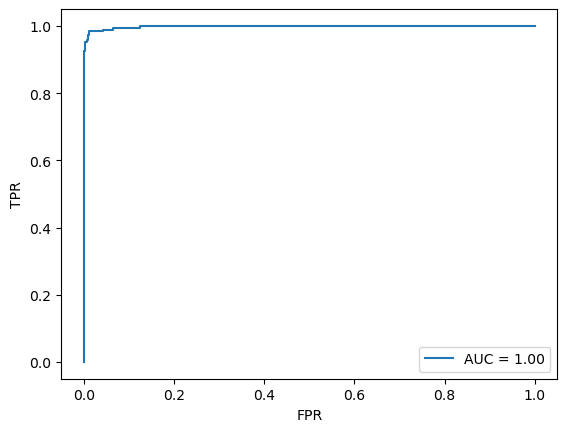

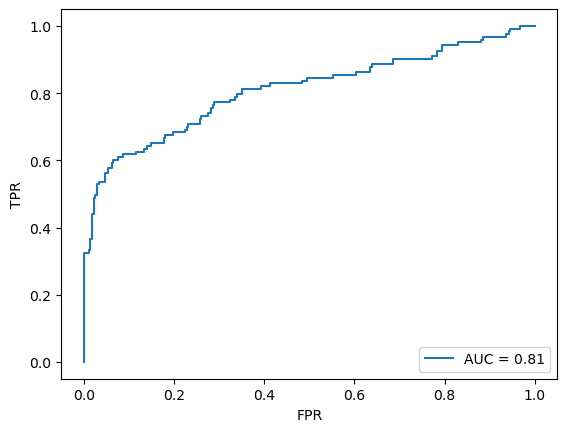

             NN-train   NN-test
Accuracy     0.976667  0.805000
Precision    0.994286  0.710280
Recall       0.930481  0.617886
F1_score     0.961326  0.660870
Specificity  0.997579  0.888087


In [30]:
metric_df_second = pd.DataFrame()
metric_list_train = print_metric(df_train_y, y_pred_train,y_proba_train, "NN-train")
metric_list_test = print_metric(df_test_y, y_pred_test, y_proba_test, "NN-test")

metric_df_second['NN-train'] = metric_list_train
metric_df_second['NN-test'] = metric_list_test

print(metric_df_second)

In [31]:
metric_df_first['diff'] = metric_df_first['NN-train'] - metric_df_first['NN-test']
metric_df_second['diff'] = metric_df_second['NN-train'] - metric_df_second['NN-test']

print("1차 모델")
display(metric_df_first)
print("2차 모델")
display(metric_df_second)

1차 모델


,NN-train,NN-test,diff
Accuracy,0.996667,0.897500,0.099167
Precision,1.000000,0.879630,0.120370
Recall,0.989305,0.772358,0.216947
F1_score,0.994624,0.822511,0.172113
Specificity,1.000000,0.953069,0.046931


2차 모델


,NN-train,NN-test,diff
Accuracy,0.976667,0.805000,0.171667
Precision,0.994286,0.710280,0.284005
Recall,0.930481,0.617886,0.312595
F1_score,0.961326,0.660870,0.300456
Specificity,0.997579,0.888087,0.109492
